In [ ]:
#Uncomment to install dependencies, run once
#%pip install -r ../requirements.txt

In [2]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

### Data Collection

In [3]:
weather = pd.read_excel("../dataset/openmeteo_makassar_weather.xlsx")

In [4]:
weather.head()

,time,temperature_2m_mean,temperature_2m_max,sunshine_duration,precipitation_sum,apparent_temperature_mean,wind_speed_10m_max,shortwave_radiation_sum,weather_code,temperature_2m_min
0,2010-01-01,26.6,28.0,32535.21,6.9,31.4,12.3,16.71,61,24.8
1,2010-01-02,26.6,28.1,40311.63,2.8,31.5,14.5,19.30,61,25.3
2,2010-01-03,26.4,28.3,35355.65,1.4,31.5,14.3,16.99,53,24.7
3,2010-01-04,25.9,27.0,29237.88,7.5,30.9,10.4,15.13,61,25.1
4,2010-01-05,25.3,27.4,18944.19,30.3,29.9,13.8,11.56,63,24.5


In [5]:
weather.shape

(5844, 10)

In [6]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   time                       5844 non-null   datetime64[ns]
 1   temperature_2m_mean        5844 non-null   float64       
 2   temperature_2m_max         5844 non-null   float64       
 3   sunshine_duration          5844 non-null   float64       
 4   precipitation_sum          5844 non-null   float64       
 5   apparent_temperature_mean  5844 non-null   float64       
 6   wind_speed_10m_max         5844 non-null   float64       
 7   shortwave_radiation_sum    5844 non-null   float64       
 8   weather_code               5844 non-null   int64         
 9   temperature_2m_min         5844 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 456.7 KB


In [7]:
weather.isna().sum()

time                         0
temperature_2m_mean          0
temperature_2m_max           0
sunshine_duration            0
precipitation_sum            0
apparent_temperature_mean    0
wind_speed_10m_max           0
shortwave_radiation_sum      0
weather_code                 0
temperature_2m_min           0
dtype: int64

### Data Preparation

In [8]:
input = weather.drop(['time','temperature_2m_mean','temperature_2m_max','apparent_temperature_mean','temperature_2m_min'], axis = 1)
output = weather['temperature_2m_mean']
print("Feature will be used: ", list(input.columns))

Feature will be used:  ['sunshine_duration', 'precipitation_sum', 'wind_speed_10m_max', 'shortwave_radiation_sum', 'weather_code']


In [9]:
input.head()

,sunshine_duration,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,weather_code
0,32535.21,6.9,12.3,16.71,61
1,40311.63,2.8,14.5,19.30,61
2,35355.65,1.4,14.3,16.99,53
3,29237.88,7.5,10.4,15.13,61
4,18944.19,30.3,13.8,11.56,63


In [10]:
output.head()

0    26.6
1    26.6
2    26.4
3    25.9
4    25.3
Name: temperature_2m_mean, dtype: float64

### Data Split

In [11]:
#Split the dataset: 70% for training and 30% for testing
X_train,X_test,y_train, y_test = train_test_split(input,output, test_size=0.3,shuffle=False)

### Model Selection

In [12]:
#Using dict to simplyfy calling process
Models = {
  "Linear Regression": linear_model.LinearRegression(),
  "Gradient Boosting": GradientBoostingRegressor(random_state=1),
  "AdaBoost": AdaBoostRegressor(random_state=1),
  "XGBoost": XGBRegressor(random_state=1),
  "CatBoost": CatBoostRegressor(random_state=1,verbose=0),
  "LightGBM": LGBMRegressor(random_state=1, verbose=-1),
  "SVR Linear": make_pipeline(StandardScaler(), SVR(kernel="linear", C=1.0, epsilon=0.2)),
  "SVR RBF": make_pipeline(StandardScaler(),SVR(kernel="rbf",C=1.0, epsilon=0.2)),
  "SVR Polynomial": make_pipeline(StandardScaler(), SVR(kernel="poly", C=1.0, epsilon=0.2)),
}

### Model Training & Evaluation

In [13]:
#Function Train + Evaluate + Ploting
def train_evaluate_plot(model,name,X_train,X_test,y_train,y_test,show_plot=True):
  time_start = time.perf_counter()
  model.fit(X_train,y_train)
  duration = time.perf_counter() - time_start

  y_pred = model.predict(X_test)

  metrics = {
    "model": name,
    "mae": mae(y_test,y_pred),
    "rmse": rmse(y_test,y_pred),
    "mape": mape(y_test,y_pred),
    "r2": r2(y_test,y_pred),
    "train_duration": duration,
  }

  if show_plot:
    plt.figure(figsize=(8,5))
    plt.scatter(y_test,y_pred,alpha=0.5,color="blue",label="Predicted")
    min_val = min(y_test.min(),y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val,max_val],[min_val, max_val], color="red", linestyle="--",label="Ideal Line")
    plt.title(f"Actual vs Predicted Temperature ({name})")
    plt.xlabel("Actual Temperature (°C)")
    plt.ylabel("Predicted Temperature (°C)")
    plt.legend()
    plt.grid(True)
    plt.show()

  return metrics
    

### Model Result

Training Linear Regression...


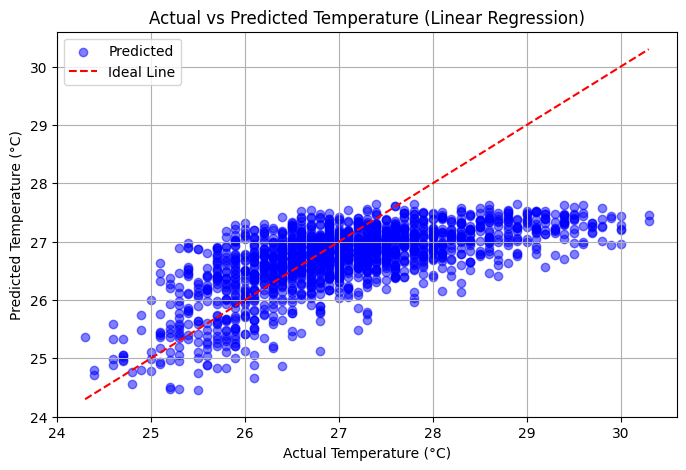

Training Gradient Boosting...


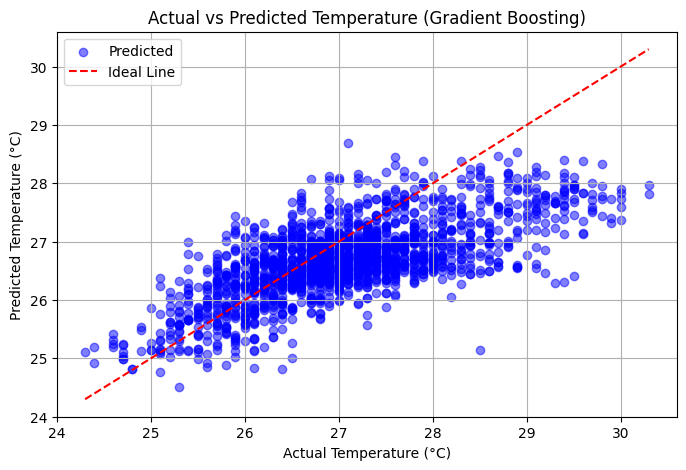

Training AdaBoost...


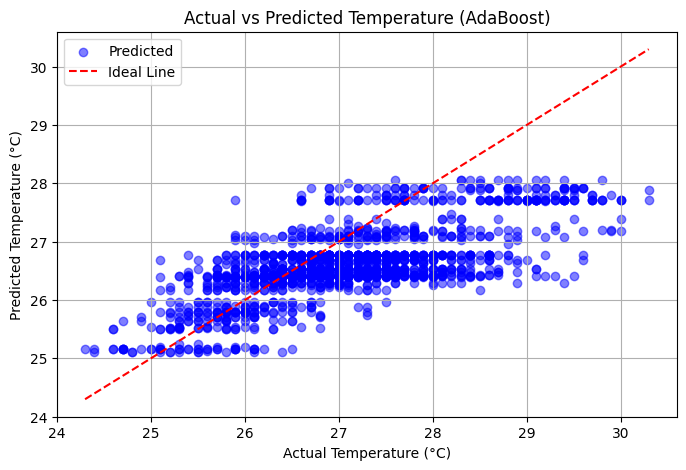

Training XGBoost...


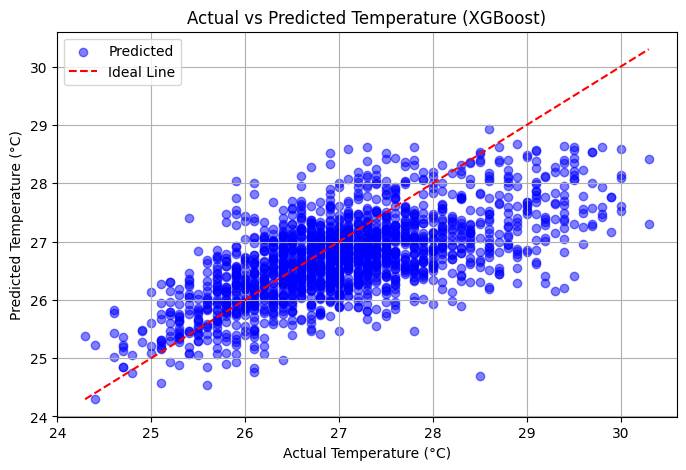

Training CatBoost...


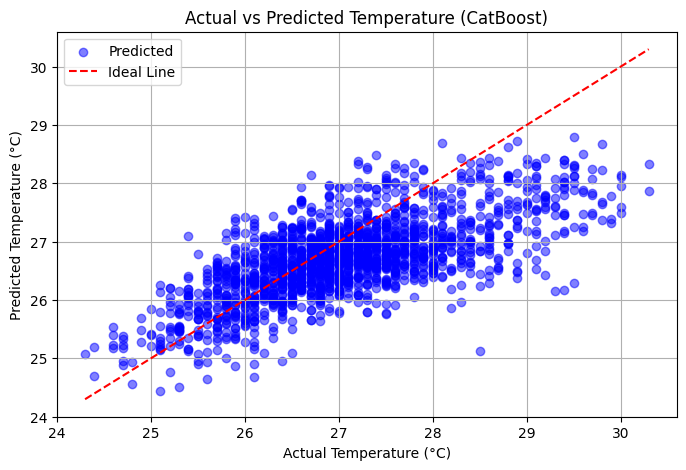

Training LightGBM...


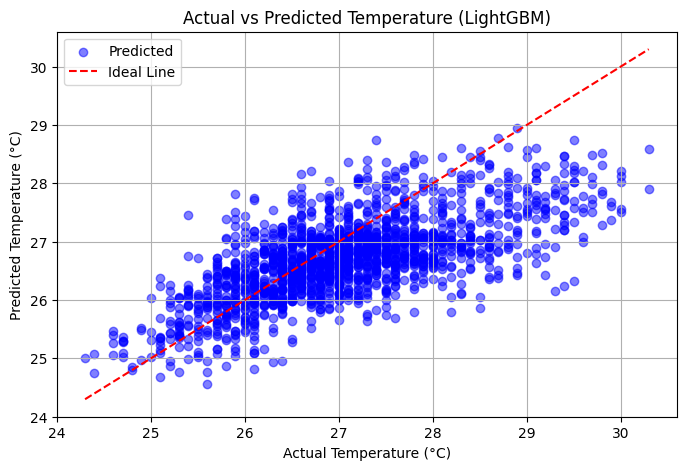

Training SVR Linear...


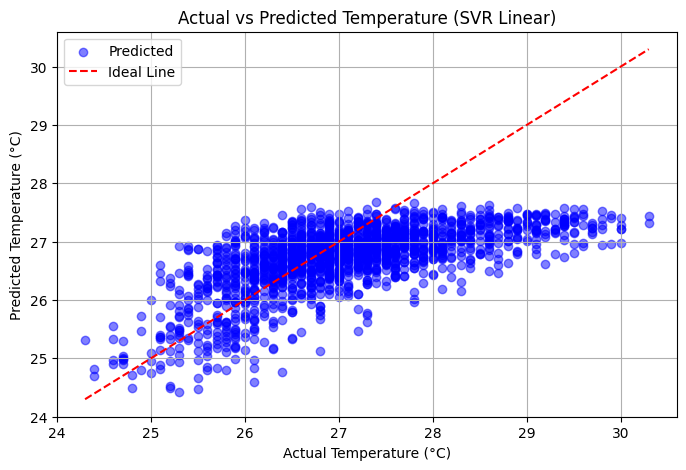

Training SVR RBF...


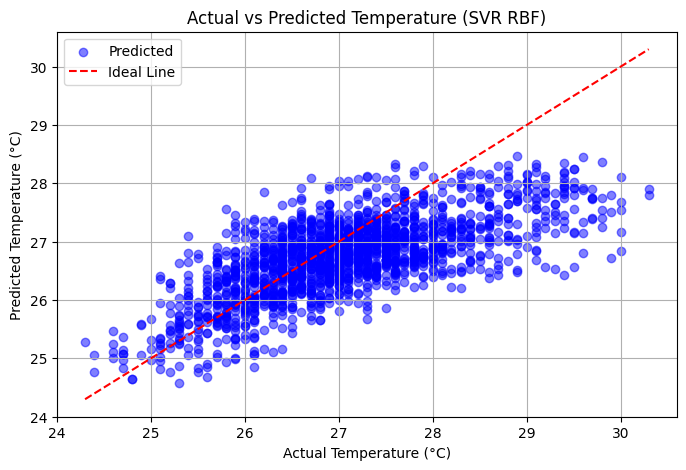

Training SVR Polynomial...


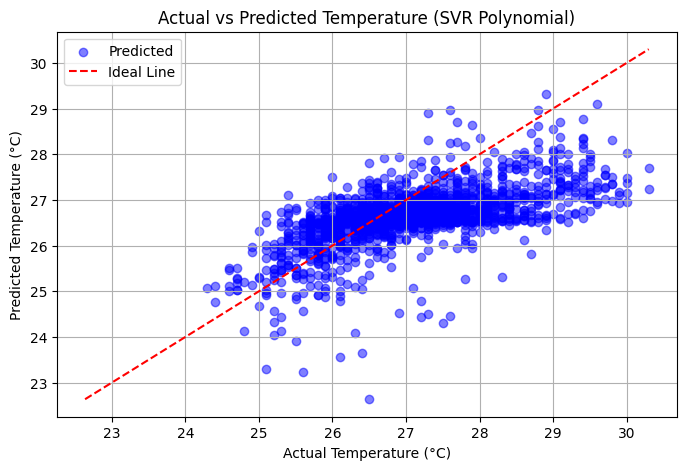


=== Model Comparation Summary ===
            model      mae     rmse     mape       r2  train_duration
          SVR RBF 0.616616 0.808175 0.022407 0.380097        0.265239
         CatBoost 0.632058 0.822020 0.022973 0.358675        1.399280
Gradient Boosting 0.634856 0.827152 0.023049 0.350643        0.343309
         LightGBM 0.640190 0.835441 0.023270 0.337563        1.777934
          XGBoost 0.653079 0.855761 0.023752 0.304947        0.214810
Linear Regression 0.650831 0.863045 0.023608 0.293065        0.005039
       SVR Linear 0.650463 0.864404 0.023593 0.290837        0.455767
         AdaBoost 0.674254 0.872489 0.024442 0.277508        0.080537
   SVR Polynomial 0.691282 0.914746 0.025089 0.205829        0.591700


In [14]:
results = []
for name,model in Models.items():
  print(f"Training {name}...")
  metrics = train_evaluate_plot(model,name, X_train,X_test,y_train,y_test,show_plot=True)
  results.append(metrics)

results_df = pd.DataFrame(results).sort_values("r2", ascending=False)

print("\n=== Model Comparation Summary ===")
print(results_df.to_string(index=False))